In [297]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [298]:
from collections import defaultdict
import copy
import os
import pprint
import functools
from pathlib import Path
from itertools import repeat

import hydra
import duckdb
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches
import matplotlib.colors
import seaborn as sns
font_scale = 7
sns.set_theme(style='ticks', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [299]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

BinderException: Binder Error: Failed to attach database: database with name "runs" already exists

In [ ]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

# Run queries

### Datasets

In [ ]:
dataset_cols = """
    Dataset.id,
    state_dimension,
    time_step_count,
    time_step_count_drop_first,
    observe_every_n_time_steps,
"""

In [ ]:
dataset_info = pl.DataFrame(dict(
    dataset_name=[*repeat('KuramotoSivashinsky', 3), *repeat('NavierStokes', 3)],
    state_dimension=[256, 512, 1024, 3*10*10, 3*64*64, 3*256*256],
    state_dimension_latex=['256', '512', '1024', r'$10\times10$', r'$64\times64$', r'$256\times256$'],
    sampling_time_step_count=[*repeat(5, 3), *repeat(10, 3)],
    multiple=1,
))
dataset_info

##### Kuramoto-Sivashinsky

In [502]:
dataset_name, dataset_name_latex = 'KuramotoSivashinsky', 'Kuramoto-Sivashinsky'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
    join ATan on Dataset.Observe = ATan.id
    where true
    and state_dimension in (select state_dimension from dataset_info where dataset_name = {dataset_name!r})
    and floating_point_precision = 32
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
    and predicted_state_count = 20
""")
assert len(dataset_rows) == 3
dataset_multiple = 3

##### Navier-Stokes

In [501]:
dataset_name, dataset_name_latex = 'NavierStokes', r'Navier-Stokes'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    join ATan on Dataset.Observe = ATan.id
    where true
    and state_dimension in (select state_dimension from dataset_info where dataset_name = {dataset_name!r})
    and time_step_count in (2000, 6000)
    and observe_every_n_time_steps in (10, 100)
    and (
        time_step_size = 1e-3 and state_dimension < 3*256*256
        or
        time_step_size = 1e-4 and state_dimension = 3*256*256
    )
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
    and predicted_state_initial_condition_std = 1.0
    and predicted_state_count = 20
""")
assert len(dataset_rows) == 3
dataset_multiple = 3

### Models

In [503]:
ns_for_hyperparameters = 'NavierStokesDim64'
filepaths = duckdb.sql(f"""
    select
        dataset_name, label, format('{{}}/TopK_{{}}_T{{}}.csv', if(dataset_name = 'NavierStokes', {ns_for_hyperparameters!r}, dataset_name), label, sampling_time_step_count) as filepath
    from dataset_info
    cross join (
        select * as label from (values ('EnSF'), ('EnFF-OT'), ('EnFF-F2P'))
    )
    where
        dataset_name in ('KuramotoSivashinsky', 'NavierStokes')
""").pl()
filepath_exists = []
for f in filepaths.get_column('filepath'):
    f = Path(f).expanduser()
    exists = f.exists()
    if not exists:
        print(f"File path does not exist: '{f}'")
    filepath_exists.append(exists)
filepaths = pl.DataFrame(dict(
    dataset_name=filepaths['dataset_name'],
    label=filepaths['label'],
    filepath=filepaths.get_column('filepath'),
    exists=filepath_exists,
))
assert filepaths['exists'].any()
duckdb.sql("""
set variable hyperparameter_filepaths = (
    select list(filepath) from filepaths where exists
)
""")
hyperparameters = duckdb.sql(f"""
    select
        if(filepaths.dataset_name = {ns_for_hyperparameters!r}, 'NavierStokes', filepaths.dataset_name) as dataset_name,
        label,
        epsilon_alpha,
        epsilon_beta,
        sigma_min,
        lambda,
    from read_csv(getvariable(hyperparameter_filepaths), filename=true, union_by_name=true) as csv_data
    join filepaths
    on csv_data.filename = filepaths.filepath
    where k = 1
""").pl()
hyperparameters.filter(dataset_name='NavierStokes')

dataset_name,label,epsilon_alpha,epsilon_beta,sigma_min,lambda
str,str,f64,f64,f64,f64
"""NavierStokes""","""EnSF""",1.0,0.275,null,null
"""NavierStokes""","""EnSF""",1.0,0.275,null,null
"""NavierStokes""","""EnSF""",1.0,0.275,null,null
"""NavierStokes""","""EnFF-OT""",null,null,0.00001,0.05
"""NavierStokes""","""EnFF-OT""",null,null,0.00001,0.05
…,…,…,…,…,…
"""NavierStokes""","""EnFF-OT""",null,null,0.00001,0.05
"""NavierStokes""","""EnFF-OT""",null,null,0.00001,0.05
"""NavierStokes""","""EnFF-F2P""",null,null,0.001,0.005


In [504]:
hyperparameters_classical_ks = pl.DataFrame(dict(
    dataset_name='KuramotoSivashinsky',
    label=['BPF', 'EnKF-PO', 'iEnKF-PO', 'ESRF', 'LETKF'],
    inflation=[1.5, 1.0, 1.4, 1.0, 1.0],
    localization=[None, 8.0, None, 8.0, 8.0],
))
hyperparameters_classical_ns = pl.DataFrame(dict(
    dataset_name='NavierStokes',
    label=['BPF', 'EnKF-PO', 'iEnKF-PO', 'ESRF', 'LETKF'],
    inflation=[None, 1.1, 1.6, 1.7, 1.0],
    localization=[None, 8.0, None, 8.0, 6.0],
))
hyperparameters_classical = pl.concat([hyperparameters_classical_ks, hyperparameters_classical_ns])
hyperparameters_classical

dataset_name,label,inflation,localization
str,str,f64,f64
"""KuramotoSivashinsky""","""BPF""",1.5,null
"""KuramotoSivashinsky""","""EnKF-PO""",1.0,8.0
"""KuramotoSivashinsky""","""iEnKF-PO""",1.4,null
"""KuramotoSivashinsky""","""ESRF""",1.0,8.0
"""KuramotoSivashinsky""","""LETKF""",1.0,8.0
"""NavierStokes""","""BPF""",null,null
"""NavierStokes""","""EnKF-PO""",1.1,8.0
"""NavierStokes""","""iEnKF-PO""",1.6,null
"""NavierStokes""","""ESRF""",1.7,8.0


In [505]:
hyperparameters = pl.concat([hyperparameters, hyperparameters_classical], how='diagonal')
hyperparameters

dataset_name,label,epsilon_alpha,epsilon_beta,sigma_min,lambda,inflation,localization
str,str,f64,f64,f64,f64,f64,f64
"""KuramotoSivashinsky""","""EnSF""",1.0,0.275,null,null,null,null
"""KuramotoSivashinsky""","""EnSF""",1.0,0.275,null,null,null,null
"""KuramotoSivashinsky""","""EnSF""",1.0,0.275,null,null,null,null
"""NavierStokes""","""EnSF""",1.0,0.275,null,null,null,null
"""NavierStokes""","""EnSF""",1.0,0.275,null,null,null,null
…,…,…,…,…,…,…,…
"""NavierStokes""","""BPF""",null,null,null,null,null,null
"""NavierStokes""","""EnKF-PO""",null,null,null,null,1.1,8.0
"""NavierStokes""","""iEnKF-PO""",null,null,null,null,1.6,null


##### EnsF

In [506]:
label = 'EnSF'
ensf_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r} as label,
        epsilon_alpha as var2,
        epsilon_beta as var1,
    from Model
    join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id
    join Bao2024EnsembleScoreMatching on ScoreMatchingMarginal.DiffusionPath = Bao2024EnsembleScoreMatching.id
    where true
    and sampling_time_step_count in (select sampling_time_step_count from dataset_info where dataset_name = {dataset_name!r})
    and (epsilon_alpha, epsilon_beta) in (select epsilon_alpha, epsilon_beta from hyperparameters where label = {label!r})
""")
ensf_multiple = (
    len(hyperparameters.filter(label=label)[['epsilon_alpha', 'epsilon_beta']].unique())
)
assert len(ensf_rows) == ensf_multiple

##### EnFF-OT

In [507]:
label = 'EnFF-OT'
enff_ot_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        ConditionalOptimalTransport.sigma_min as var1,
        Constant.constant as var2,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    join hyperparameters on (
            hyperparameters.label = {label!r}
        and
            (hyperparameters.sigma_min, hyperparameters.lambda) = (ConditionalOptimalTransport.sigma_min, Constant.constant)
    )
    where true
    and sampling_time_step_count in (select sampling_time_step_count from dataset_info where dataset_name = {dataset_name!r})
""")
enff_ot_multiple = (
    len(hyperparameters.filter(label=label)[['sigma_min', 'lambda']].unique())
)
assert len(enff_ot_rows) == enff_ot_multiple

##### EnFF-F2P

In [508]:
label = 'EnFF-F2P'
enff_f2p_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        PreviousPosteriorToPredictive.sigma_min as var1,
        Constant.constant as var2,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    join hyperparameters on (
            hyperparameters.label = {label!r}
        and
            (hyperparameters.sigma_min, hyperparameters.lambda) = (PreviousPosteriorToPredictive.sigma_min, Constant.constant)
    )
    where true
    and sampling_time_step_count in (select sampling_time_step_count from dataset_info where dataset_name = {dataset_name!r})
""")
enff_f2p_multiple = (
    len(hyperparameters.filter(label=label)[['sigma_min', 'lambda']].unique())
)
assert len(enff_f2p_rows) == enff_f2p_multiple

##### BPF

In [509]:
label = 'BPF'
bpf_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        constant as var1,
        null as var2,
    from Model
    join BootstrapParticleFilter on Model.id = BootstrapParticleFilter.id
    join ConstantScale on Model.InflationScale = ConstantScale.id
    where true
    and constant in (select inflation from hyperparameters where label = {label!r})
""")
bpf_multiple = (
    len(hyperparameters.filter(pl.col('inflation').is_null().not_(), label=label)['inflation'].unique())
)
assert len(bpf_rows) == bpf_multiple

##### EnKF-PO

In [510]:
label = 'EnKF-PO'
enkf_po_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        constant as var1,
        loc_radius_gc as var2,
    from Model
    join EnsembleKalmanFilterPerturbedObservations on Model.id = EnsembleKalmanFilterPerturbedObservations.id
    join ConstantScale on Model.InflationScale = ConstantScale.id
    where true
    and (constant, loc_radius_gc) in (select inflation, localization from hyperparameters where label = {label!r})
""")
enkf_po_multiple = (
    len(hyperparameters.filter(label=label)[['inflation', 'localization']].unique())
)
assert len(enkf_po_rows) == enkf_po_multiple

##### iEnKF-PO

In [511]:
label = 'iEnKF-PO'
ienkf_po_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        constant as var1,
        null as var2,
    from Model
    join EnsembleKalmanFilterPerturbedObservationsIterative on Model.id = EnsembleKalmanFilterPerturbedObservationsIterative.id
    join ConstantScale on Model.InflationScale = ConstantScale.id
    where true
    and constant in (select inflation from hyperparameters where label = {label!r})
""")
ienkf_po_multiple = (
    len(hyperparameters.filter(label=label)[['inflation', 'localization']].unique())
)
assert len(ienkf_po_rows) == ienkf_po_multiple

##### ESRF

In [512]:
label = 'ESRF'
esrf_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        constant as var1,
        loc_radius_gc as var2,
    from Model
    join EnsembleRandomizedSquareRootFilter on Model.id = EnsembleRandomizedSquareRootFilter.id
    join ConstantScale on Model.InflationScale = ConstantScale.id
    where true
    and (constant, loc_radius_gc) in (select inflation, localization from hyperparameters where label = {label!r})
""")
esrf_multiple = (
    len(hyperparameters.filter(label=label)[['inflation', 'localization']].unique())
)
assert len(esrf_rows) == esrf_multiple

##### LETKF

In [513]:
label = 'LETKF'
letkf_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        constant as var1,
        loc_radius_gc as var2,
    from Model
    join LocalEnsembleTransformKalmanFilter on Model.id = LocalEnsembleTransformKalmanFilter.id
    join ConstantScale on Model.InflationScale = ConstantScale.id
    where true
    and (constant, loc_radius_gc) in (select inflation, localization from hyperparameters where label = {label!r})
""")
letkf_multiple = (
    len(hyperparameters.filter(label=label)[['inflation', 'localization']].unique())
)
assert len(letkf_rows) == letkf_multiple

### General

In [514]:
rows = duckdb.sql(f"""
    select
        alt_id,
        model_rows.*,
        dataset_rows.*,
        rng_seed,
    from Conf
    join dataset_rows on Conf.Dataset = dataset_rows.id
    join (
        select * from ensf_rows
        union
        select * from enff_ot_rows
        union
        select * from enff_f2p_rows
        union
        select * from bpf_rows
        union
        select * from enkf_po_rows
        union
        select * from ienkf_po_rows
        union
        select * from esrf_rows
        union
        select * from letkf_rows
    ) as model_rows on Conf.Model = model_rows.id
    where true
    and rng_seed in (462133975, 979497033, 97616566, 715319214, 19704671)
""")
rng_seed_multiple = 5
model_multiple = 8
multiple = rng_seed_multiple * dataset_multiple * model_multiple
assert len(rows) == multiple, f'{len(rows) = } != {multiple}'

In [515]:
duckdb.sql("""
select * from rows where label = 'EnFF-OT'
""")

┌──────────┬───────┬─────────┬────────┬────────┬───────┬─────────────────┬─────────────────┬────────────────────────────┬────────────────────────────┬───────────┐
│  alt_id  │  id   │  label  │  var2  │  var1  │ id_1  │ state_dimension │ time_step_count │ time_step_count_drop_first │ observe_every_n_time_steps │ rng_seed  │
│ varchar  │ int64 │ varchar │ double │ double │ int64 │      int64      │      int64      │           int64            │           int64            │   int64   │
├──────────┼───────┼─────────┼────────┼────────┼───────┼─────────────────┼─────────────────┼────────────────────────────┼────────────────────────────┼───────────┤
│ 4excsfpb │   922 │ EnFF-OT │  1e-05 │   0.05 │    50 │            1024 │            6000 │                       2000 │                          4 │ 462133975 │
│ noxw30ct │   922 │ EnFF-OT │  1e-05 │   0.05 │    34 │             512 │            6000 │                       2000 │                          4 │  19704671 │
│ ud4e9mwi │   922 │ E

In [516]:
filepaths = duckdb.sql("""
select alt_id, format('~/out/dafm/runs/{}/dataset_metrics.csv', alt_id) as filepath from rows
""").pl()
filepath_exists = []
for f in filepaths.get_column('filepath'):
    f = Path(f).expanduser()
    exists = f.exists()
    if not exists:
        print(f"File path does not exist: '{f}'")
    filepath_exists.append(exists)
filepaths = pl.DataFrame(dict(alt_id=filepaths['alt_id'], filepath=filepaths.get_column('filepath'), exists=filepath_exists))
assert filepaths['exists'].any()
duckdb.sql("""
set variable dataset_metrics_filepaths = (
    select list(filepath) from filepaths where exists
)
""")

File path does not exist: '/home/ttransue/out/dafm/runs/6qdj3wy5/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/dbcf07ar/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/7743uybl/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/k0gprkq9/dataset_metrics.csv'


##### RMSE and CRPS    

In [533]:
observation_steps_back = 50
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
    and step > time_step_count - observe_every_n_time_steps * {observation_steps_back}
""")
logged_metrics.show(max_width=100)

┌──────────┬───────┬──────────┬───┬────────────────────┬──────────────────────┐
│  alt_id  │  id   │  label   │ … │        crps        │         rmse         │
│ varchar  │ int64 │ varchar  │   │       double       │        double        │
├──────────┼───────┼──────────┼───┼────────────────────┼──────────────────────┤
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.8373212803344658 │  0.05862395320775264 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │  1.854286986029979 │ 0.059179805959984344 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.7984861880074634 │  0.05745608995685615 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.5160021038319147 │  0.04865004498980478 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.4135396431672422 │ 0.045458005374872226 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.3316239900433786 │  0.04284025725333857 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.2715733641838192 │ 0.040924770234163216 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.2077568938864924 │  0.03891411345649191 │
│ 3t1f5bda │   627 │ EnFF-F2P │ … │ 1.24

##### Time (seconds)

In [518]:
observation_steps_back = None
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
""")
logged_metrics.show(max_width=100)

┌──────────┬───────┬──────────┬───┬────────────────────┬─────────────────────┐
│  alt_id  │  id   │  label   │ … │        crps        │        rmse         │
│ varchar  │ int64 │ varchar  │   │       double       │       double        │
├──────────┼───────┼──────────┼───┼────────────────────┼─────────────────────┤
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │ 3.8367201863516796 │ 0.12338241799346159 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │  3.877309912729519 │  0.1283200098020327 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │   4.46831811821953 │ 0.17383330008520786 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │  4.998590759783442 │  0.2190529291657897 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │  5.367054985170574 │    0.25457030127364 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │  5.629641295343946 │  0.2824639946350609 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │  5.701646273959135 │ 0.29257269052834795 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │   5.61002180643324 │ 0.28843867073904295 │
│ 7quf9hr6 │   627 │ EnFF-F2P │ … │  5.3587651266742

In [534]:
if observation_steps_back is None:
    observation_steps_back = duckdb.sql(f"""
        select
            count(*) as observation_step_count,
        from logged_metrics
        group by alt_id
        order by observation_step_count desc
        limit 1
    """).fetchall()[0][0]
failed_before_finish = duckdb.sql(f"""
    select
        alt_id,
        count(*) as observation_step_count,
    from logged_metrics
    group by alt_id
    having observation_step_count < {observation_steps_back}
""")
failed_before_finish
# assert len(logged_metrics) > 0 and len(failed_before_finish) == 0, failed_before_finish

┌─────────┬────────────────────────┐
│ alt_id  │ observation_step_count │
│ varchar │         int64          │
├─────────┴────────────────────────┤
│              0 rows              │
└──────────────────────────────────┘

In [535]:
logged_metrics = duckdb.sql("""
    select *
    from logged_metrics
    where alt_id not in (select alt_id from failed_before_finish)
""")

In [536]:
duckdb.sql("""
    select
        label, count(*) as 'Num. Failed',
    from rows
    where
        alt_id not in (
            select alt_id from logged_metrics
        )
    group by label
    order by label desc
""")

┌──────────┬─────────────┐
│  label   │ Num. Failed │
│ varchar  │    int64    │
├──────────┼─────────────┤
│ iEnKF-PO │           2 │
│ LETKF    │           2 │
│ EnSF     │           9 │
│ EnKF-PO  │           2 │
│ EnFF-OT  │           2 │
│ EnFF-F2P │           2 │
│ ESRF     │           2 │
└──────────┴─────────────┘

In [537]:
group_by = """
    alt_id,
    rng_seed,
    state_dimension,
    label,
    var1,
    var2,
"""
logged_metrics_means = duckdb.sql(f"""
    select
        {group_by}
        mean(time_s) as time_s_mean,
        mean(rmse) as rmse,
        mean(crps) as crps,
    from logged_metrics
    group by
        {group_by}
""")
logged_metrics_means.show(max_width=100)

┌──────────┬───────────┬───┬──────────────────────┬──────────────────────┬─────────────────────┐
│  alt_id  │ rng_seed  │ … │     time_s_mean      │         rmse         │        crps         │
│ varchar  │   int64   │   │        double        │        double        │       double        │
├──────────┼───────────┼───┼──────────────────────┼──────────────────────┼─────────────────────┤
│ mdxwv9cm │ 979497033 │ … │   0.9758851643600042 │  0.03501320525215311 │ 0.41257190399738486 │
│ e1zdtiqd │ 462133975 │ … │ 0.007494200080000084 │  0.15767580999830685 │   2.492230795710481 │
│ 5iqoylz6 │  19704671 │ … │ 0.015564196199999998 │ 0.018647420870148323 │  0.4330134722334688 │
│ ftgjjvg3 │  19704671 │ … │ 0.007988333760001111 │  0.08149358157363049 │  2.6076457933951955 │
│ 7xh8isnm │  19704671 │ … │   1.7469442214199988 │ 0.024690631168362457 │ 0.41470074814927427 │
│ qe2h1w1k │ 462133975 │ … │ 0.007674534619999989 │  0.11392170932867136 │  1.8226710328919802 │
│ zaj4whar │  19704671 │ … │  

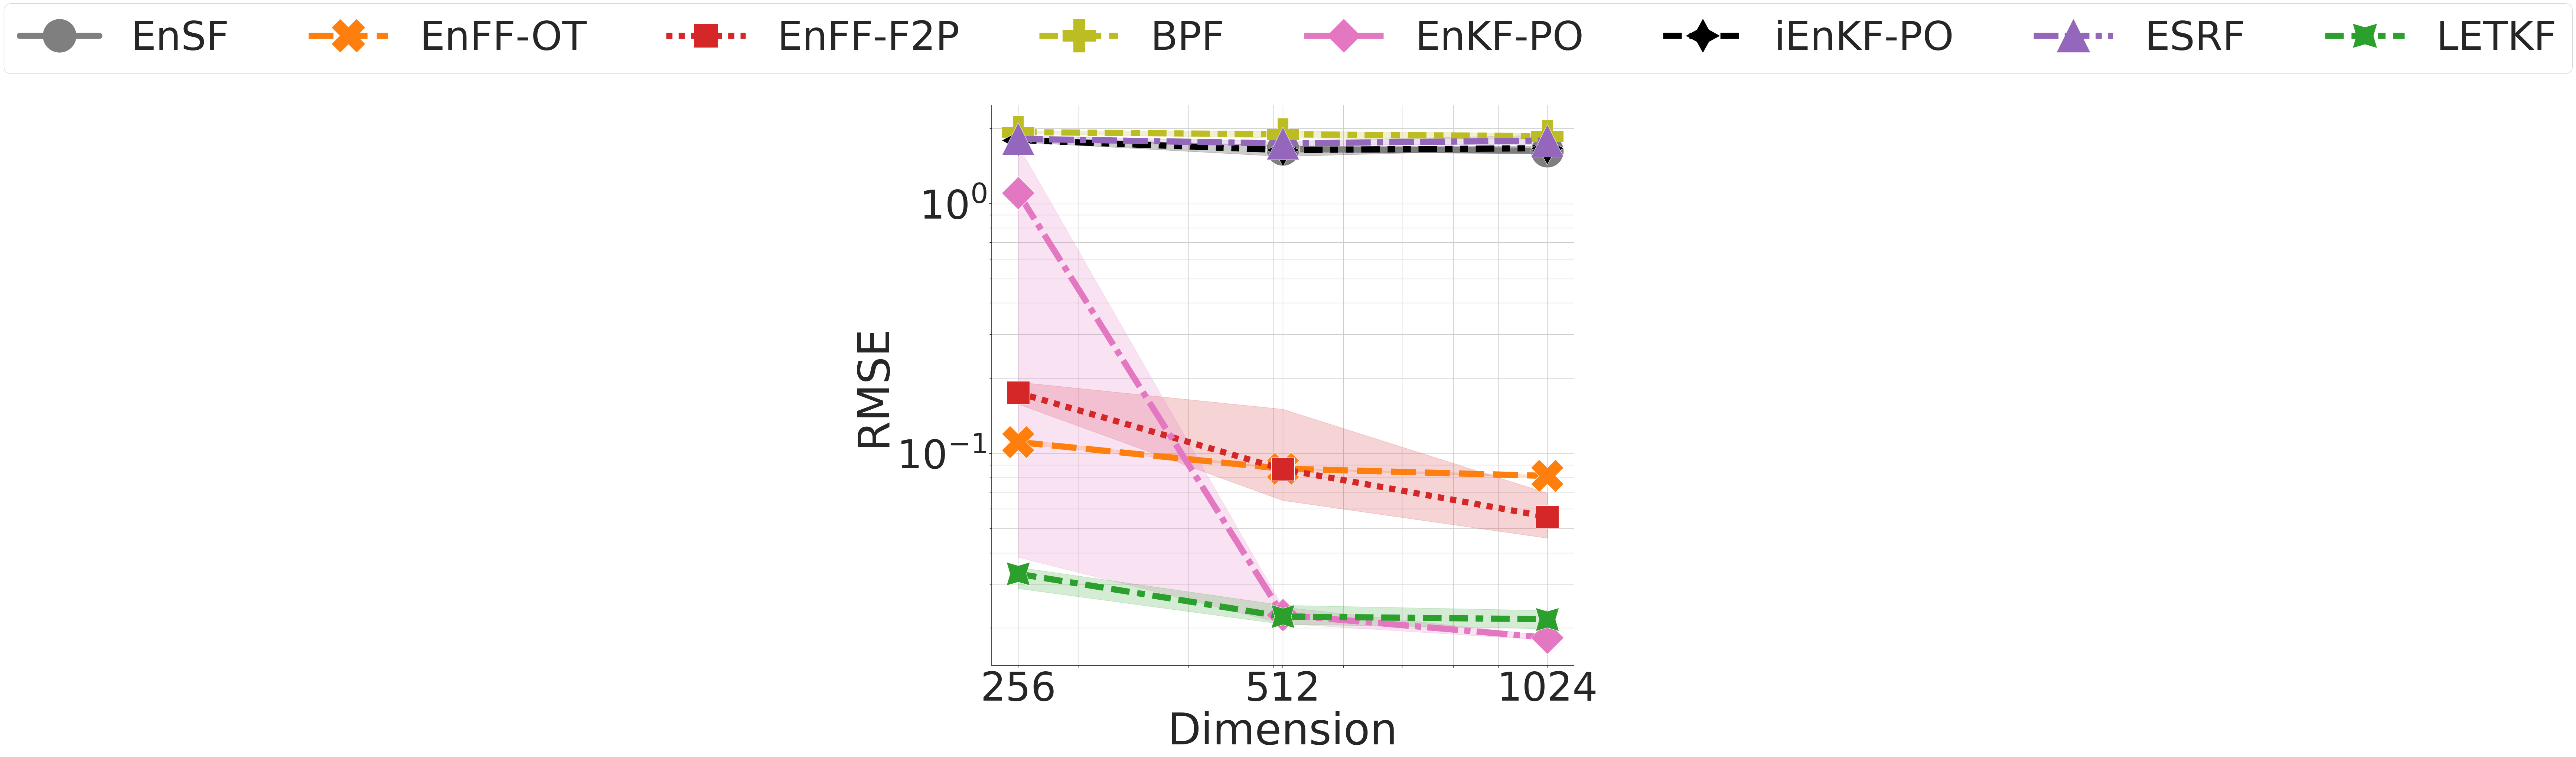

In [542]:
hue_order = ['EnSF', 'EnFF-OT', 'EnFF-F2P', 'BPF', 'EnKF-PO', 'iEnKF-PO', 'ESRF', 'LETKF']
plot_data = duckdb.sql(f"""
    select
        *
    from logged_metrics_means
    join dataset_info on dataset_info.dataset_name = {dataset_name!r} and logged_metrics_means.state_dimension = dataset_info.state_dimension
""").pl()
xticks, xticklabels = plot_data[['state_dimension', 'state_dimension_latex']].unique().sort('state_dimension').iter_columns()
palette = {
    'EnSF': 'tab:gray',
    'EnFF-OT': 'tab:orange',
    'EnFF-F2P': 'tab:red',
    'BPF': 'tab:olive',
    'EnKF-PO': 'tab:pink',
    'iEnKF-PO': 'black',
    'ESRF': 'tab:purple',
    'LETKF': 'tab:green',
}
y = 'rmse'
plot_metric = (
    sns.relplot(
        kind='line',
        estimator='mean',
        errorbar=('pi', 100),
        data=plot_data,
        x='state_dimension',
        y=y,
        hue='label',
        hue_order=hue_order,
        style='label',
        style_order=hue_order,
        palette=palette,
        markers=True,
        markersize=64,
        linewidth=12,
        height=20,
        aspect=1.1,
    )
    .set(
        xscale='log',
        yscale='log',
        # title=dataset_name,
        xticks=xticks,
        xticklabels=xticklabels,
        xlabel='Dimension',
        ylabel=y.upper(),
        # ylabel='Time (s)',
    )
)
sns.move_legend(
    plot_metric,
    loc='upper center',
    ncol=len(hue_order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot_metric.facet_data():
    ax = plot_metric.axes[row, col]
    ax.grid()
    ax.grid(which='minor')
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: ''))
    # ax.minorticks_off()

In [543]:
plots.save_all_subfigures(plot_metric, y.upper())
dataset_name, observation_steps_back

('KuramotoSivashinsky', 50)

In [142]:
temp = plot_data.filter(sampling_time_step_count=10, rng_seed=97616566).select('alt_id', 'label')
duckdb.sql("""select * from temp""")

┌──────────┬──────────┐
│  alt_id  │  label   │
│ varchar  │ varchar  │
├──────────┼──────────┤
│ w45lmnof │ EnFF-F2P │
│ 5m61kobi │ EnFF-OT  │
│ hk71m4om │ EnSF     │
└──────────┴──────────┘